<a href="https://colab.research.google.com/github/swanjala849-Mas/Machine-Learning/blob/main/Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style for clean visuals
sns.set_theme(style="whitegrid")


In [4]:
# Seed for reproducibility
np.random.seed(42)

# Generate synthetic data for 120 smallholder agricultural zones
# Average seasonal rainfall ranges from 400mm to 1200mm
seasonal_rainfall_mm = np.random.uniform(400, 1200, 120)
# Crop yield formula with some random environmental noise (pests, soil quality)
# Base yield + effect of rainfall + random variation
maize_yield_mt_per_ha = 0.5 + (0.0035 * seasonal_rainfall_mm) + np.random.normal(0, 0.4, 120)
# Structure into a Pandas DataFrame
agri_data = pd.DataFrame({
    'Rainfall_mm': seasonal_rainfall_mm,
    'Maize_Yield_MT': maize_yield_mt_per_ha
})
# Display the first few rows
print("--- First 5 Records of the Dataset ---")
print(agri_data.head())


--- First 5 Records of the Dataset ---
   Rainfall_mm  Maize_Yield_MT
0   699.632095        2.667891
1  1160.571445        4.430935
2   985.595153        3.792740
3   878.926787        2.990838
4   524.814912        2.455300


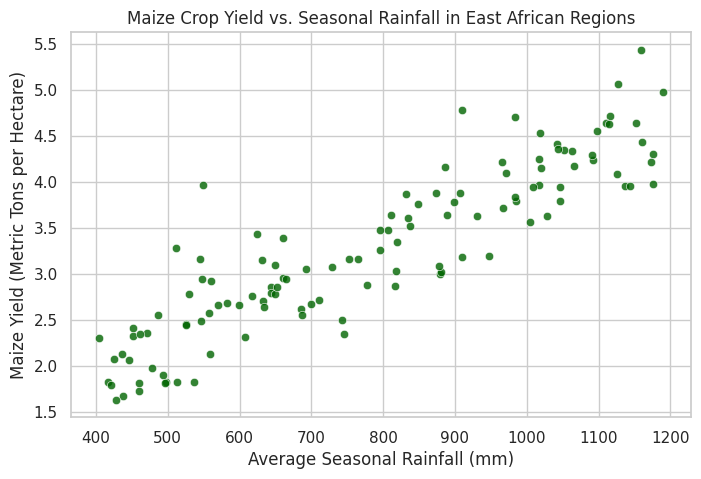

Pearson Correlation Coefficient: 0.8988


In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=agri_data, x='Rainfall_mm', y='Maize_Yield_MT',
color='darkgreen', alpha=0.8)
plt.title('Maize Crop Yield vs. Seasonal Rainfall in East African Regions')
plt.xlabel('Average Seasonal Rainfall (mm)')
plt.ylabel('Maize Yield (Metric Tons per Hectare)')
plt.show()

# Calculate the correlation coefficient
correlation = agri_data['Rainfall_mm'].corr(agri_data['Maize_Yield_MT'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

In [6]:
# Separate features (X) and target variable (y)
# X must be a 2D array or DataFrame for Scikit-learn
X = agri_data[['Rainfall_mm']]
y = agri_data['Maize_Yield_MT']
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 96 samples
Testing set size: 24 samples


In [7]:
# Initialize the model
crop_yield_model = LinearRegression()
# Train the model on the training data
crop_yield_model.fit(X_train, y_train)
# Extract learned parameters: Intercept (b0) and Slope (b1)
print(f"Model Intercept (β0): {crop_yield_model.intercept_:.4f}")
print(f"Model Slope/Coefficient (β1): {crop_yield_model.coef_[0]:.4f}")

Model Intercept (β0): 0.6404
Model Slope/Coefficient (β1): 0.0034


In [8]:
# Predict yield for the test set
y_pred = crop_yield_model.predict(X_test)
# Calculate Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} MT/ha")
print(f"R-squared (R²) Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 0.1610
Root Mean Squared Error (RMSE): 0.4012 MT/ha
R-squared (R²) Score: 0.8027


In [9]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

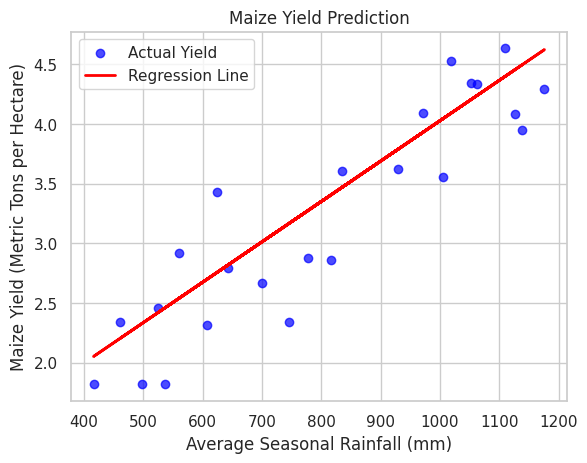

In [11]:
plt.scatter(X_test, y_test, color='blue', label='Actual Yield', alpha=0.7)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Maize Yield Prediction')
plt.xlabel('Average Seasonal Rainfall (mm)')
plt.ylabel('Maize Yield (Metric Tons per Hectare)')
plt.legend()
plt.grid(True)
plt.show()